In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/housing.csv.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
y = df["median_house_value"].values

In [7]:
X = df.drop(
    ["median_house_value", "ocean_proximity"],
    axis=1
).values

In [8]:
print(X.shape)
print(y.shape)

(20433, 8)
(20433,)


In [9]:
X = (X - X.mean(axis=0)) / X.std(axis=0)
y = (y - y.mean()) / y.std()

In [10]:
n_samples = X.shape[0]
n_features = X.shape[1]

w = np.zeros(n_features)
b = 0

learning_rate = 0.01
epochs = 10000

In [11]:
losses = []
for epoch in range(epochs):

    # Forward pass
    y_pred = X @ w + b

    # Gradients
    dw = (-2/n_samples) * (X.T @ (y - y_pred))
    db = (-2/n_samples) * np.sum(y - y_pred)

    # Update
    w -= learning_rate * dw
    b -= learning_rate * db

    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch} "
            f"Loss {loss:.5f}"
        )

Epoch 0 Loss 1.00000
Epoch 100 Loss 0.45485
Epoch 200 Loss 0.42103
Epoch 300 Loss 0.40486
Epoch 400 Loss 0.39359
Epoch 500 Loss 0.38553
Epoch 600 Loss 0.37972
Epoch 700 Loss 0.37550
Epoch 800 Loss 0.37242
Epoch 900 Loss 0.37016
Epoch 1000 Loss 0.36849
Epoch 1100 Loss 0.36725
Epoch 1200 Loss 0.36632
Epoch 1300 Loss 0.36563
Epoch 1400 Loss 0.36511
Epoch 1500 Loss 0.36471
Epoch 1600 Loss 0.36440
Epoch 1700 Loss 0.36417
Epoch 1800 Loss 0.36398
Epoch 1900 Loss 0.36384
Epoch 2000 Loss 0.36373
Epoch 2100 Loss 0.36364
Epoch 2200 Loss 0.36356
Epoch 2300 Loss 0.36350
Epoch 2400 Loss 0.36346
Epoch 2500 Loss 0.36342
Epoch 2600 Loss 0.36338
Epoch 2700 Loss 0.36335
Epoch 2800 Loss 0.36333
Epoch 2900 Loss 0.36331
Epoch 3000 Loss 0.36329
Epoch 3100 Loss 0.36327
Epoch 3200 Loss 0.36326
Epoch 3300 Loss 0.36324
Epoch 3400 Loss 0.36323
Epoch 3500 Loss 0.36322
Epoch 3600 Loss 0.36321
Epoch 3700 Loss 0.36320
Epoch 3800 Loss 0.36320
Epoch 3900 Loss 0.36319
Epoch 4000 Loss 0.36318
Epoch 4100 Loss 0.36318
Epoc

In [12]:
print("Weights:")
print(w)

print("Bias:")
print(b)

Weights:
[-0.74097329 -0.78622215  0.12625447 -0.15418773  0.40635848 -0.378569
  0.16680368  0.66248856]
Bias:
-1.8873250243992098e-15


In [13]:
y_pred = X @ w + b

In [14]:
mse = np.mean(
    (y - y_pred) ** 2
)

print("MSE:", mse)

MSE: 0.36309082577908286


In [15]:
ss_res = np.sum(
    (y - y_pred) ** 2
)

ss_tot = np.sum(
    (y - np.mean(y)) ** 2
)

r2 = 1 - ss_res / ss_tot

print("R2 Score:", r2)

R2 Score: 0.6369091742209172


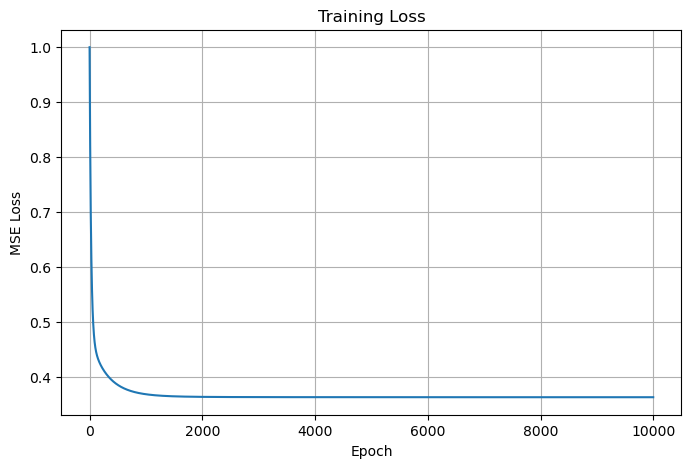

In [16]:


plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

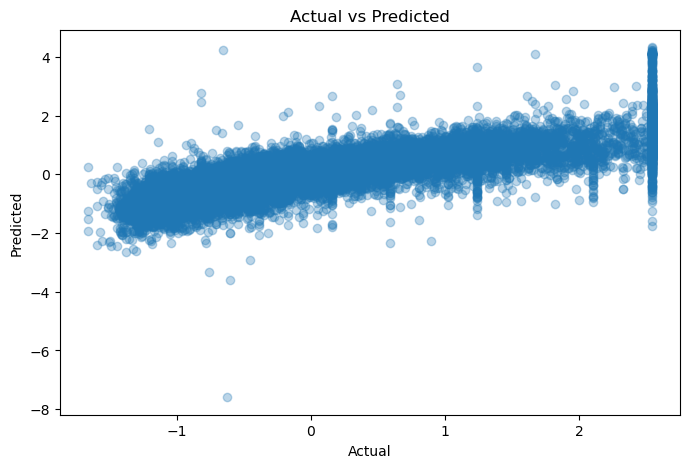

In [17]:
y_pred = X @ w + b

plt.figure(figsize=(8,5))

plt.scatter(y, y_pred, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()